In [1]:
import os
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
import lime
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost


/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

In [2]:
# Implementación base de datos alternativa
# ruta
ruta_darwin = os.path.expanduser("/Users/joseromerodegaetano/Desktop/DARWIN/DARWIN.csv") 

try:

    # Se carga el dataset
    df = pd.read_csv(ruta_darwin)

    x = df.drop(columns=['class'])
    y = df['class']

    # Se busca la col ID si existente y se filtra
    if 'ID' in x.columns:
        x = x.drop(columns=['ID'])
        print("Columna ID eliminada")

    print('Dataset DARWIN cargado correctamente')

except FileNotFoundError:
    print(f"No se encuentra el archivo .csv DARWIN en {ruta_darwin}")

Columna ID eliminada
Dataset DARWIN cargado correctamente


In [3]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df.drop(['ID', 'class'], axis = 1)

# Y contiene 'class'
Y = df['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [4]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

# Análisis de ML III

### DECISION TREE

In [5]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.82


**SHAP**

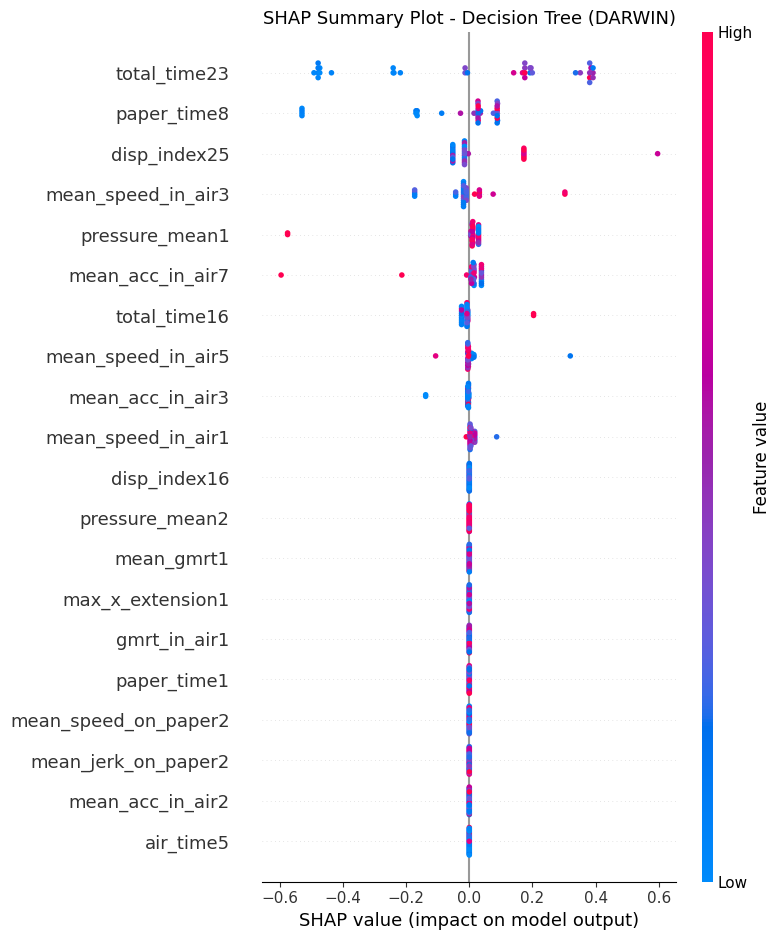

✔ Summary plot guardado.


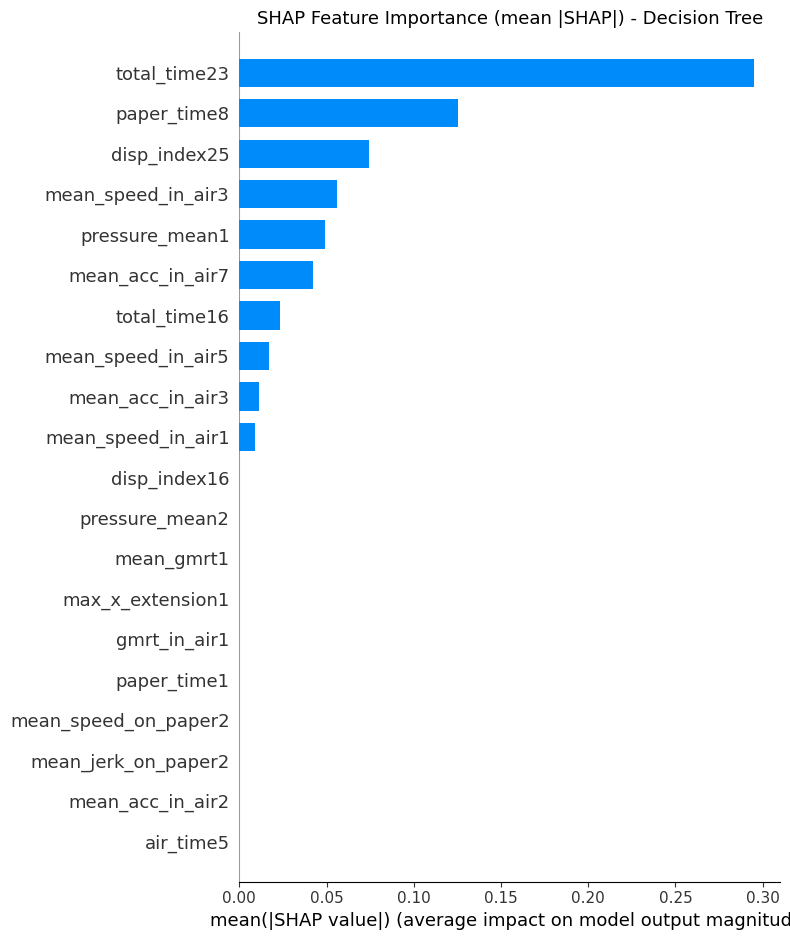

✔ Bar plot guardado.


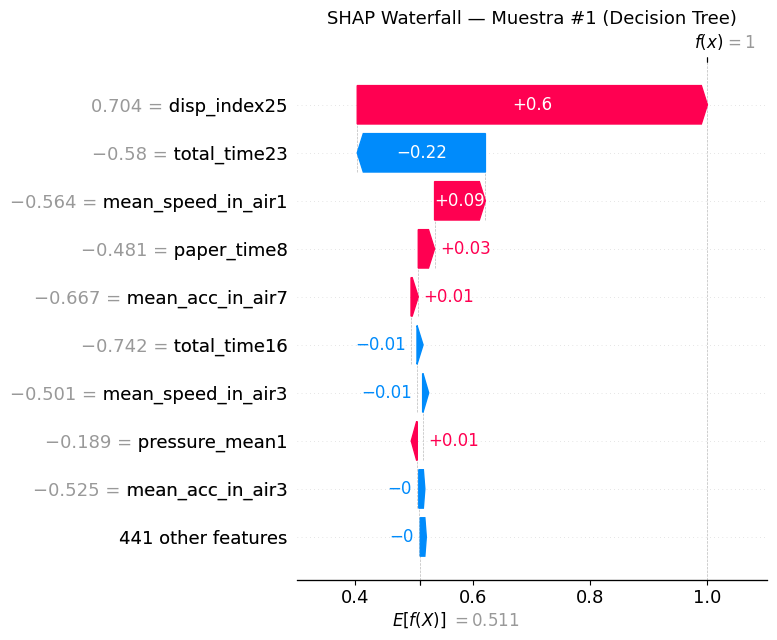

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

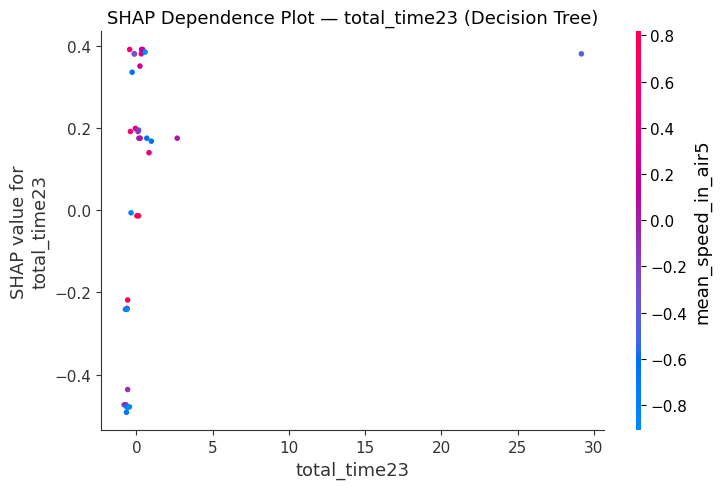

✔ Dependence plot guardado para: total_time23

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===
           Feature  Mean |SHAP|
      total_time23     0.295144
       paper_time8     0.125605
      disp_index25     0.074491
mean_speed_in_air3     0.055764
    pressure_mean1     0.049030
  mean_acc_in_air7     0.042081
      total_time16     0.023540
mean_speed_in_air5     0.017282
  mean_acc_in_air3     0.011206
mean_speed_in_air1     0.008828


In [6]:
# ============================================================
# ANÁLISIS SHAP PARA DECISION TREE
# ============================================================

# Explainer
explainer_dt = shap.TreeExplainer(tree_model) # best_tree o tree_model
 
# SHAP values
shap_values_dt = explainer_dt.shap_values(X_test_scaled)

# Se extrae la clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv = np.array(shap_values_dt)[:, :, 1]  # shape (35, 450)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Decision Tree (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot 
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Decision Tree", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot
# ============================================================
sample_idx = 1

explanation_dt = shap.Explanation(
    values=sv[sample_idx],
    base_values=explainer_dt.expected_value[1],
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_dt, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot 
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)
top_feature_idx_dt = np.argmax(mean_abs_shap_dt)
top_feature_name_dt = X.columns[top_feature_idx_dt]

plt.figure()
shap.dependence_plot(
    top_feature_idx_dt,
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_dt} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_dt}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)

feature_importance_dt_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_dt
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===")
print(feature_importance_dt_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000

Top features (peso LIME):
  total_time23 <= -0.56                          -0.3461
  disp_index25 > 0.45                            +0.2804
  -0.52 < paper_time8 <= -0.30                   +0.0865
  -0.75 < mean_acc_in_air7 <= -0.34              +0.0862
  -0.71 < mean_speed_in_air3 <= -0.26            -0.0571
  mean_speed_in_air5 > 0.30                      -0.0500
  total_time9 > 0.09                             +0.0499
  -0.33 < mean_jerk_in_air15 <= 0.37             +0.0437
  pressure_var1 > 0.56                           -0.0435
  -0.25 < mean_acc_on_paper10 <= 0.56            -0.0356
  -0.67 < mean_speed_on_paper21 <= -0.16         +0.0353
  max_y_extension8 > 0.53                        -0.0346
  gmrt_in_air8 > 0.22                            -0.0344
  mean_acc_in_air2 <= -0.66                      -0.0313
  mean_speed_in_air12 > 0.32                     +0.0263


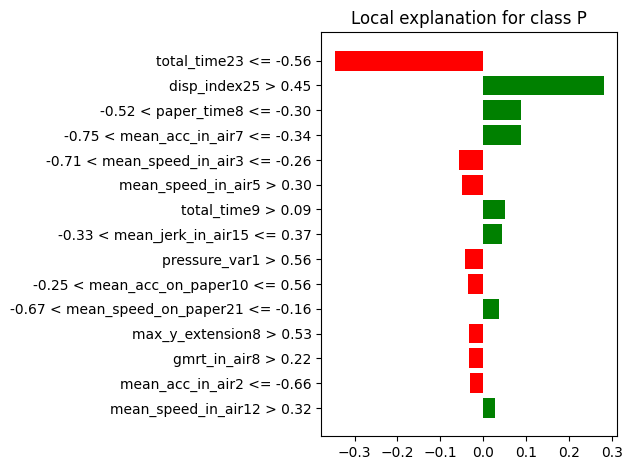


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. total_time2                               0.23106
   2. paper_time8                               0.20598
   3. mean_acc_in_air7                          0.16520
   4. disp_index2                               0.16473
   5. mean_speed_in_air3                        0.13459
   6. mean_gmrt8                                0.11697
   7. disp_index8                               0.11478
   8. pressure_mean8                            0.11299
   9. mean_acc_on_paper4                        0.11194
  10. mean_acc_on_paper2                        0.10448
  11. mean_speed_in_air5                        0.10267
  12. total_time1                               0.09964
  13. air_time6                                 0.09840
  14. mean_acc_in_air4                          0.09815
  15. pressure_mean4                            0.09813
  16. mean_jerk_in_air3                         0.09708
  17. mean_jerk_on_

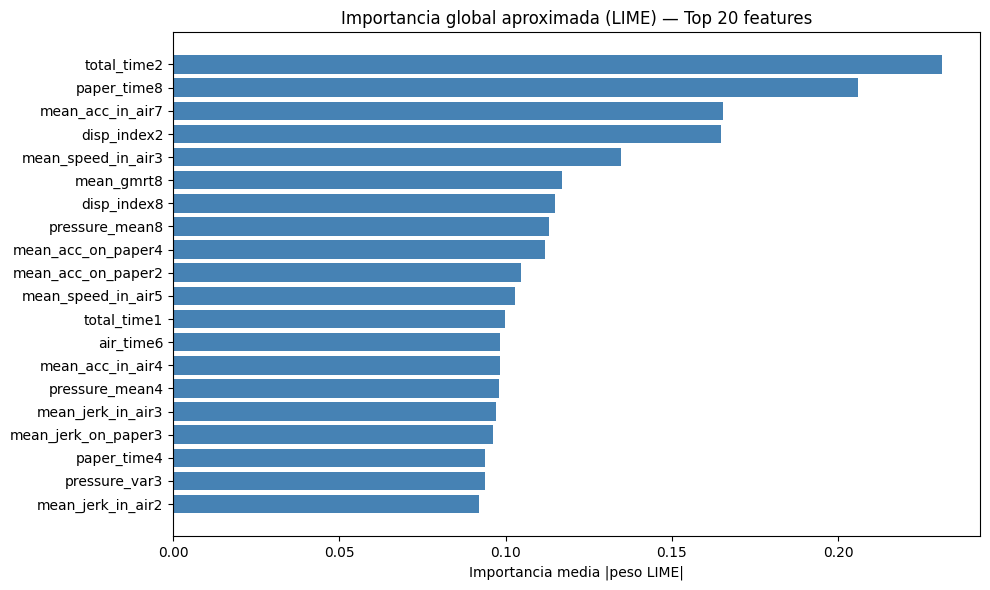

In [7]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = tree_model.predict_proba, # best_tree o tree_model
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_dt[INSTANCE_IDX]}") # Y_pred_opt Y_pred_dt
print(f"Probabilidades : H={tree_model.predict_proba([instance])[0][0]:.3f} | " # best
      f"P={tree_model.predict_proba([instance])[0][1]:.3f}")  # best
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = tree_model.predict_proba, # best
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

### RANDOM FOREST

In [8]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.68      0.83      0.75        18

    accuracy                           0.71        35
   macro avg       0.73      0.71      0.71        35
weighted avg       0.72      0.71      0.71        35

 --- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.59


**SHAP**

Shape shap_values_rf: (35, 450, 2)
Shape sv_rf: (35, 450)


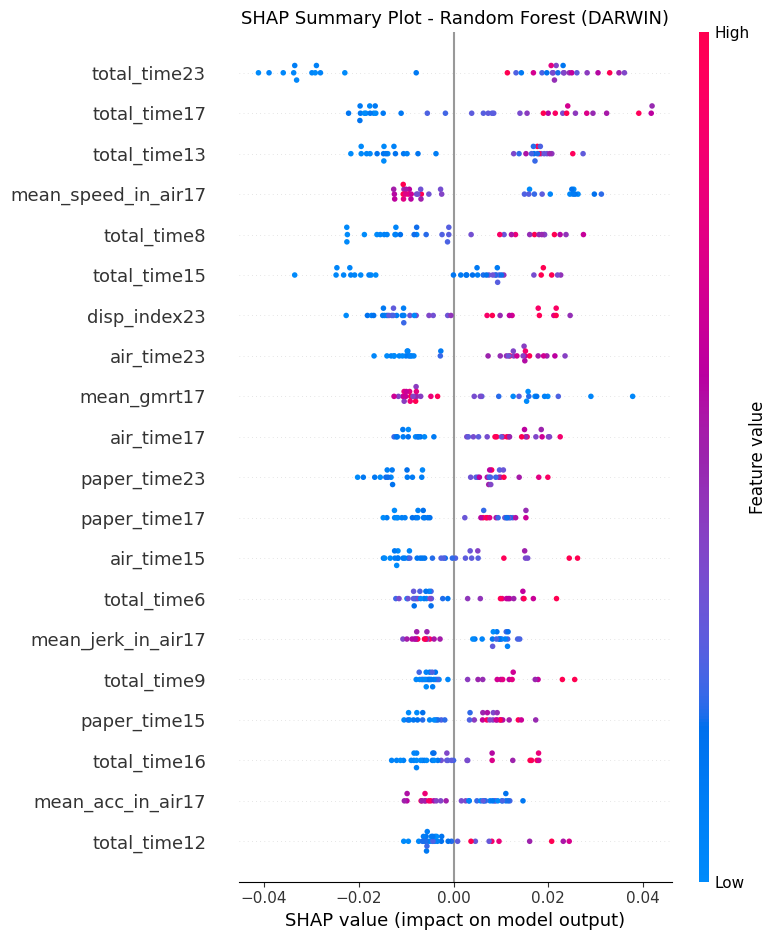

✔ Summary plot guardado.


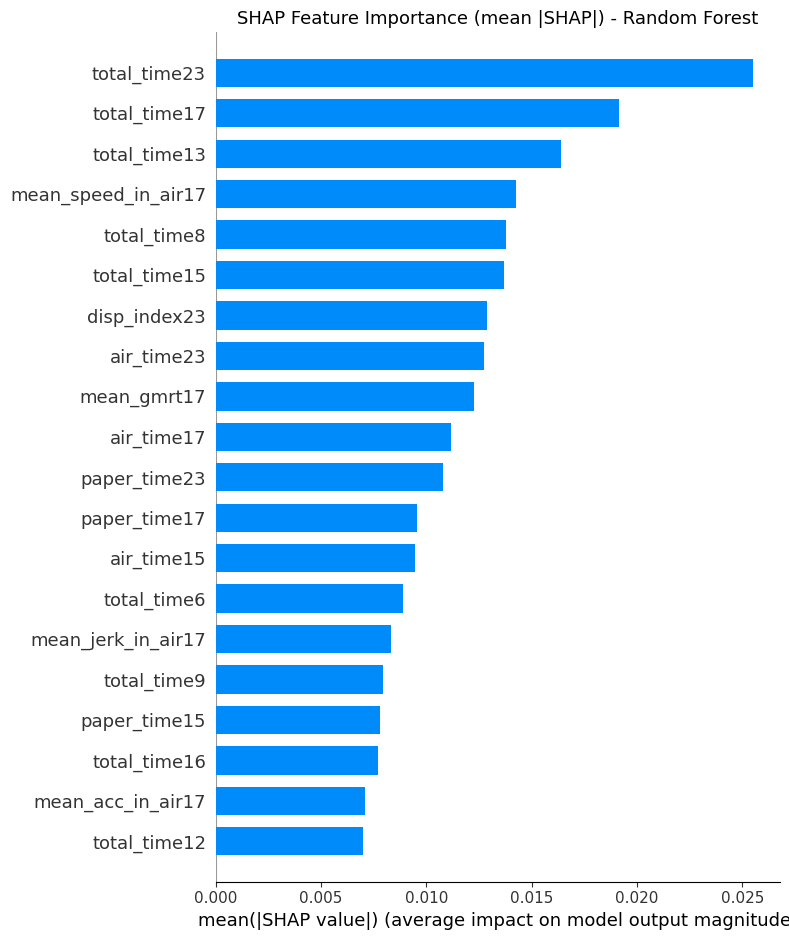

✔ Bar plot guardado.
expected_value_rf: [0.48964029 0.51035971]


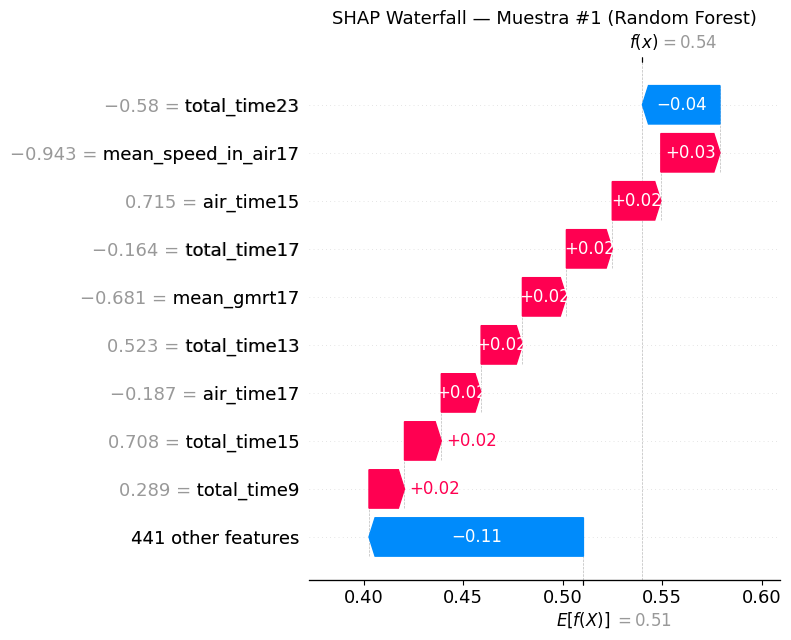

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

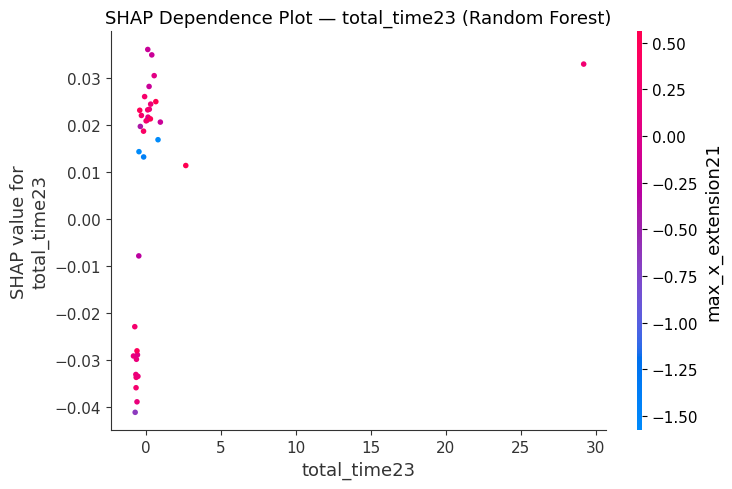

✔ Dependence plot guardado para: total_time23

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===
            Feature  Mean |SHAP|
       total_time23     0.025506
       total_time17     0.019149
       total_time13     0.016388
mean_speed_in_air17     0.014271
        total_time8     0.013788
       total_time15     0.013662
       disp_index23     0.012887
         air_time23     0.012715
        mean_gmrt17     0.012239
         air_time17     0.011150


In [9]:
# ============================================================
# ANÁLISIS SHAP PARA RANDOM FOREST
# ============================================================

# Explainer
explainer_rf = shap.TreeExplainer(rf_model) # rf_model o best_rf

# SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

# Estructura 
print("Shape shap_values_rf:", np.array(shap_values_rf).shape)

# Se extrae la clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv_rf = np.array(shap_values_rf)[:, :, 1]  # shape (35, 450)
print("Shape sv_rf:", sv_rf.shape)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Random Forest (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot
# ============================================================
sample_idx = 1

# Verificar expected_value
print("expected_value_rf:", explainer_rf.expected_value)

explanation_rf = shap.Explanation(
    values=sv_rf[sample_idx],
    base_values=explainer_rf.expected_value[1],  
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_rf, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot
# ============================================================
mean_abs_shap_rf = np.abs(sv_rf).mean(axis=0)
top_feature_idx_rf = np.argmax(mean_abs_shap_rf)
top_feature_name_rf = X.columns[top_feature_idx_rf]

plt.figure()
shap.dependence_plot(
    top_feature_idx_rf,
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_rf} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_rf}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_rf
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===")
print(feature_importance_rf_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.460 | P=0.540
  total_time23 <= -0.56                          -0.0332
  mean_speed_in_air17 <= -0.67                   +0.0233
  total_time8 <= -0.52                           -0.0202
  total_time9 > 0.09                             +0.0199
  air_time15 > -0.10                             +0.0189
  total_time15 > -0.05                           +0.0184
  total_time13 > 0.27                            +0.0174
  paper_time14 > 0.13                            +0.0151
  air_time13 > 0.16                              +0.0150
  paper_time2 <= -0.65                           -0.0140
  gmrt_in_air17 <= -0.73                         +0.0138
  paper_time15 > 0.16                            +0.0129
  total_time16 <= -0.65                          -0.0121
  -0.62 < disp_index23 <= -0.26                  -0.0119
  air_time23 <= -0.59                            -0.0118


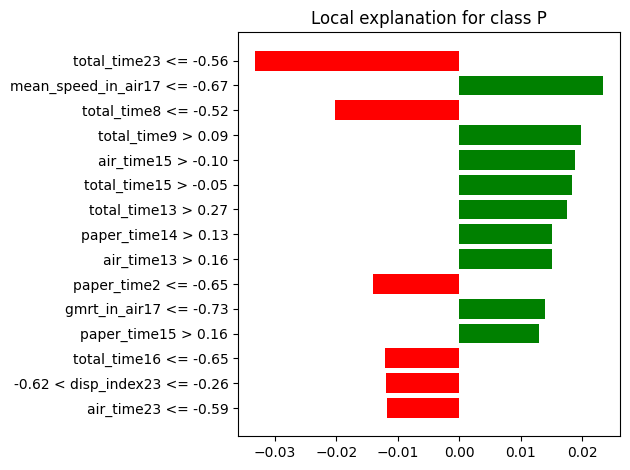


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. gmrt_on_paper7                            0.02564
   2. total_time2                               0.02253
   3. pressure_mean4                            0.02245
   4. total_time8                               0.01994
   5. total_time1                               0.01959
   6. mean_gmrt1                                0.01861
   7. mean_speed_in_air1                        0.01779
   8. paper_time2                               0.01771
   9. mean_speed_on_paper8                      0.01755
  10. disp_index2                               0.01685
  11. pressure_mean8                            0.01675
  12. paper_time6                               0.01634
  13. air_time7                                 0.01580
  14. disp_index4                               0.01563
  15. mean_acc_on_paper3                        0.01554
  16. gmrt_on_paper5                            0.01512
  17. disp_index1  

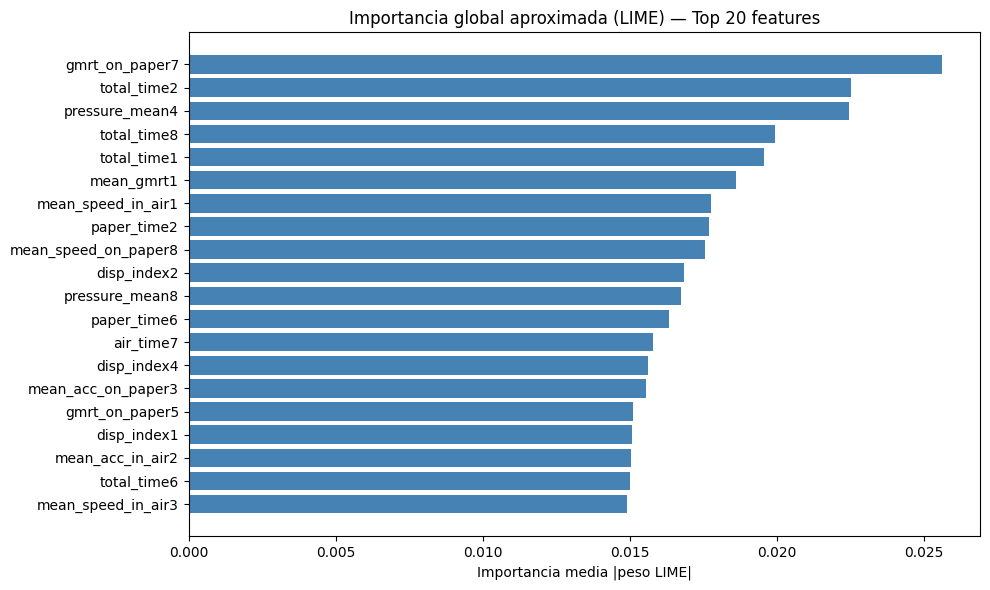

In [10]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = rf_model.predict_proba, # rf_model best_rf
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_rf[INSTANCE_IDX]}") # Y_pred_rf Y_pred_rf2
print(f"Probabilidades : H={rf_model.predict_proba([instance])[0][0]:.3f} | " # rf_model best_rf
      f"P={rf_model.predict_proba([instance])[0][1]:.3f}") # best
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = rf_model.predict_proba, # rf_model
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

### XGBOOST

In [11]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

print(f"Sensibilidad: {tp_xgb / (tp_xgb + fn_xgb):.2f}")
print(f"Especificidad: {tn_xgb / (tn_xgb + fp_xgb):.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:20:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        17
           1       0.76      0.89      0.82        18

    accuracy                           0.80        35
   macro avg       0.81      0.80      0.80        35
weighted avg       0.81      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.71


**SHAP**

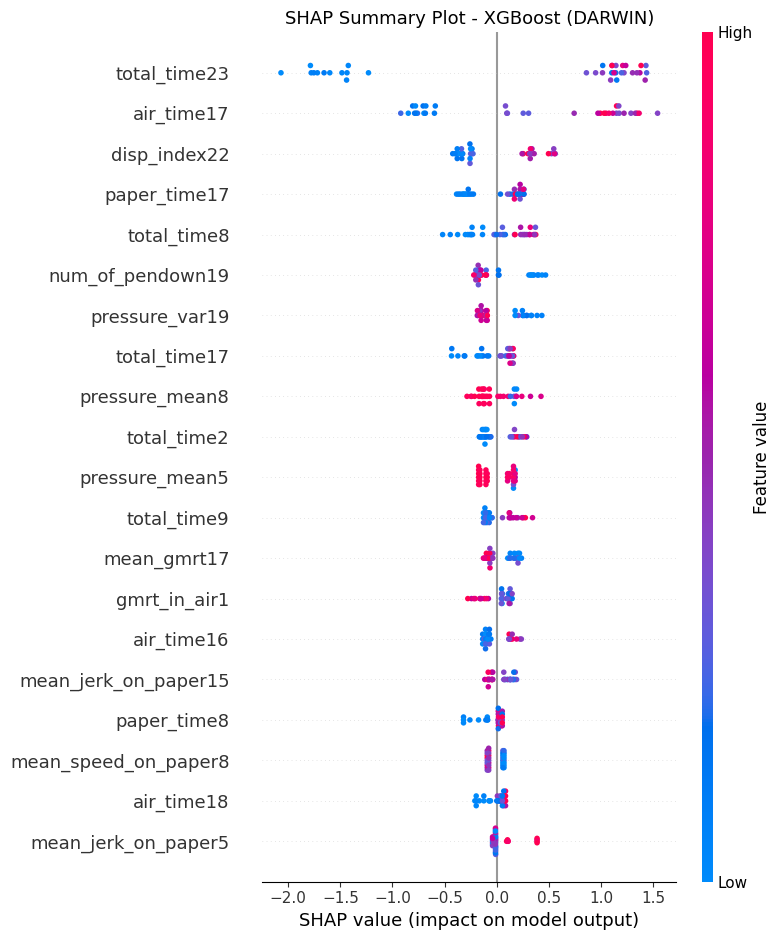

✔ Summary plot guardado.


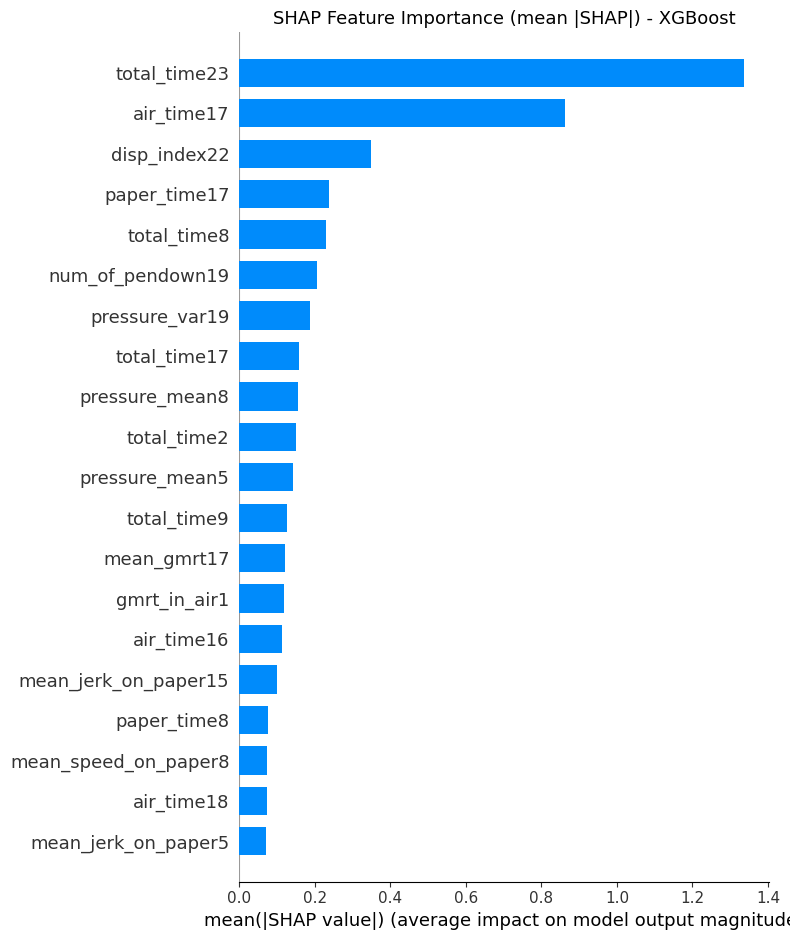

✔ Bar plot guardado.


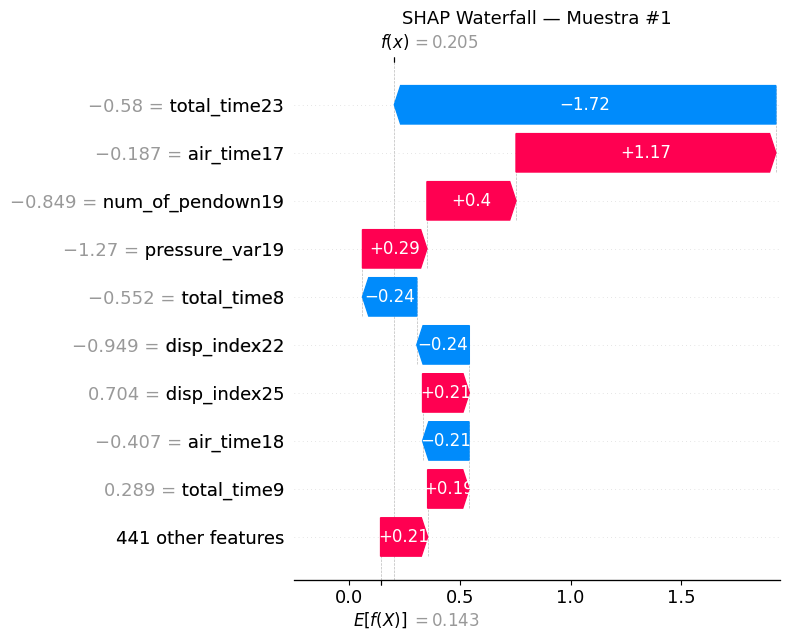

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

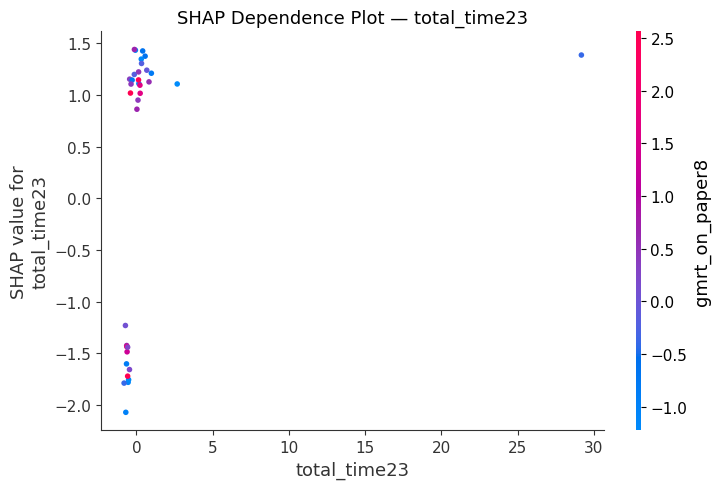

✔ Dependence plot guardado para: total_time23

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===
         Feature  Mean |SHAP|
    total_time23     1.336476
      air_time17     0.862846
    disp_index22     0.347715
    paper_time17     0.237517
     total_time8     0.229790
num_of_pendown19     0.205878
  pressure_var19     0.187848
    total_time17     0.159505
  pressure_mean8     0.156707
     total_time2     0.149764


In [12]:
# ============================================================
# ANÁLISIS SHAP PARA XGBOOST
# ============================================================

# Explainer SHAP (TreeExplainer es el óptimo para XGBoost)
explainer = shap.TreeExplainer(modelo_xgb) # 2

# Calcular los SHAP values sobre el test set
shap_values = explainer.shap_values(X_test_scaled)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - XGBoost (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot — Explicación individual
# ============================================================
# Índice de la muestra a explicar (cámbialo si quieres otra)
sample_idx = 1

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx] if hasattr(X_test_scaled, '__array__') else X_test_scaled.iloc[sample_idx].values,
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot 
# ============================================================
# Se identifica la feature con mayor impacto medio
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

plt.figure()
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features por |SHAP| medio
# ============================================================
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===")
print(feature_importance_df.head(10).to_string(index=False))

**LIME**


--- LIME XGBoost: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.449 | P=0.551

Top features (peso LIME):
  total_time23 <= -0.56                          -0.3128
  -0.27 < air_time17 <= -0.10                    +0.1122
  num_of_pendown19 <= -0.85                      +0.0815
  pressure_var19 <= -0.80                        +0.0661
  total_time8 <= -0.52                           -0.0635
  -0.24 < paper_time17 <= 0.22                   +0.0602
  disp_index22 <= -0.73                          -0.0542
  total_time9 > 0.09                             +0.0535
  air_time18 <= -0.36                            -0.0494
  -0.29 < total_time17 <= -0.08                  +0.0307
  max_y_extension4 <= -0.34                      -0.0282
  total_time2 <= -0.55                           -0.0268
  pressure_mean5 <= 0.14                         +0.0255
  gmrt_on_paper10 > 0.42                         -0.0248
  -0.68 < gmrt_in_air1 <= -0.25                  +0.0212


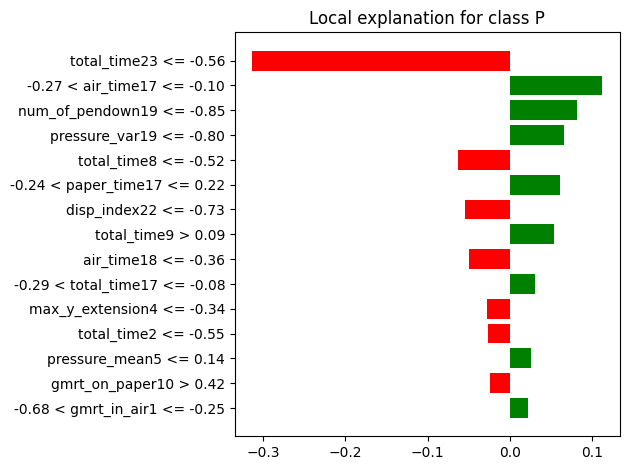


Calculando importancia global LIME (XGBoost)...

Top-20 features por importancia global LIME (XGBoost):
   1. total_time2                               0.19449
   2. air_time1                                 0.13803
   3. mean_acc_on_paper9                        0.07079
   4. total_time8                               0.06904
   5. disp_index2                               0.06902
   6. gmrt_in_air6                              0.06631
   7. pressure_mean8                            0.06125
   8. paper_time7                               0.06110
   9. total_time9                               0.06042
  10. paper_time1                               0.05909
  11. pressure_var1                             0.05896
  12. mean_jerk_on_paper5                       0.05814
  13. gmrt_in_air4                              0.05702
  14. mean_speed_on_paper9                      0.05686
  15. pressure_mean5                            0.05675
  16. mean_acc_in_air9                          0.05630

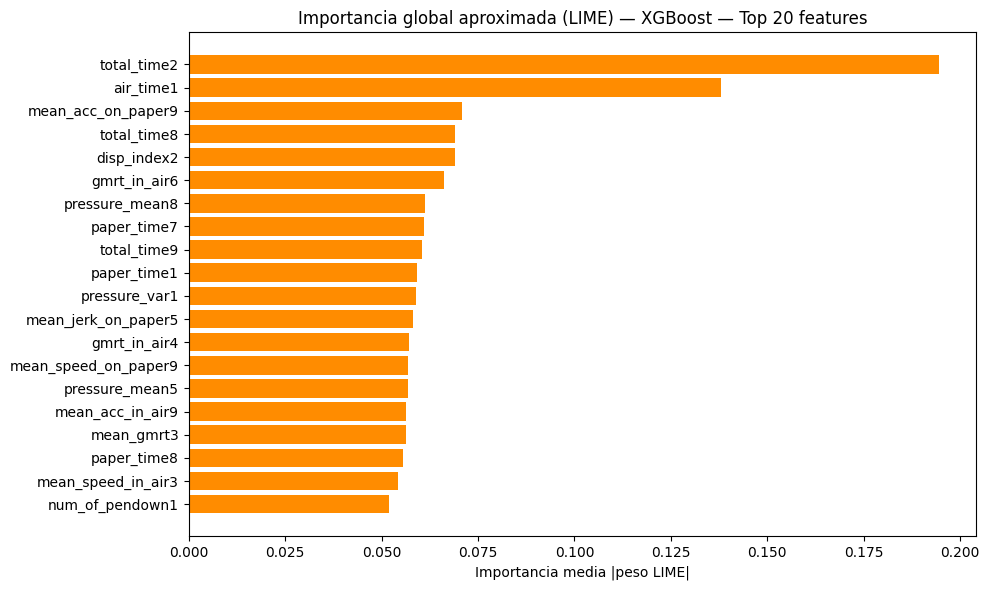

In [13]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO XGBoost
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = modelo_xgb.predict_proba, # modelo_xgb modelo_xgb2
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME XGBoost: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_xgb[INSTANCE_IDX]}") # Y_pred_xgb Y_pred_xgb2
print(f"Probabilidades : H={modelo_xgb.predict_proba([instance])[0][0]:.3f} | " # 2
      f"P={modelo_xgb.predict_proba([instance])[0][1]:.3f}") # 2
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (XGBoost)...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = modelo_xgb.predict_proba, # 2
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (XGBoost):")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="darkorange")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — XGBoost — Top 20 features")
plt.tight_layout()
plt.show()

## Gaussian Naive Bayes

In [14]:
# Modelo
gnb = GaussianNB()

# Se entrena el modelo
gnb.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb = gnb.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb))

# Sensibilidad y especificidad
tn_gnb, fp_gnb, fn_gnb, tp_gnb = confusion_matrix(Y_test, Y_pred_gnb).ravel()

print(f"Sensibilidad: {tp_gnb / (tp_gnb + fn_gnb):.2f}")
print(f"Especificidad: {tn_gnb / (tn_gnb + fp_gnb):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.76


**SHAP**

100%|██████████| 35/35 [03:42<00:00,  6.36s/it]


Shape shap_values_gnb: (35, 450, 2)
Shape sv_gnb: (35, 450)
expected_value shape: (2,)
expected_value: [0.45708337 0.54291663]
base_val usado: 0.5429166256772573


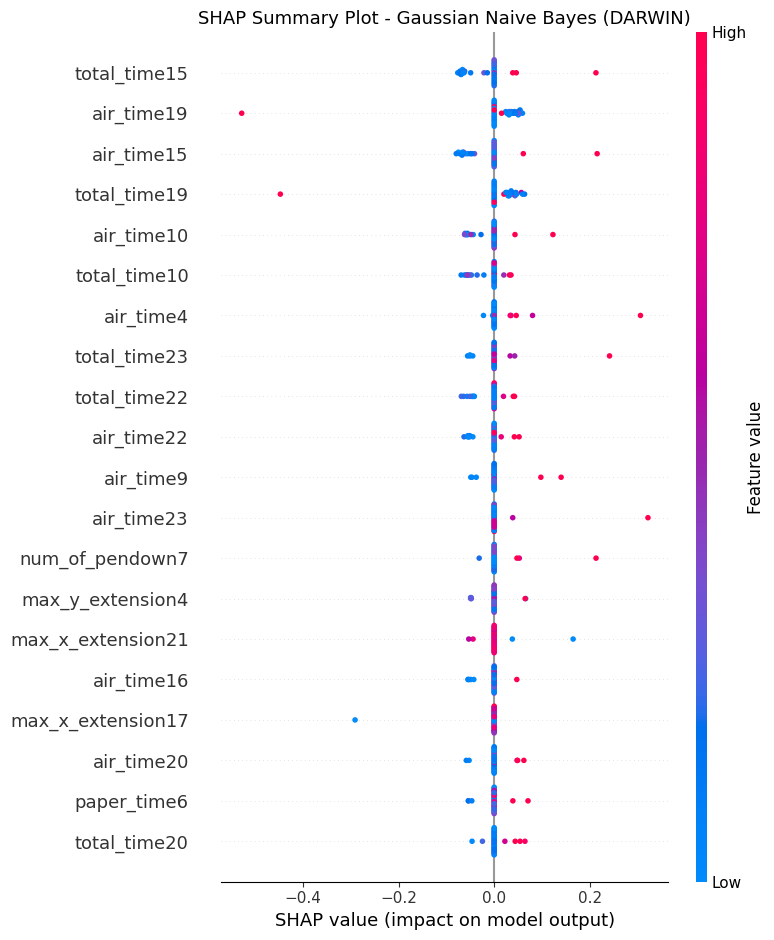

✔ Summary plot guardado.


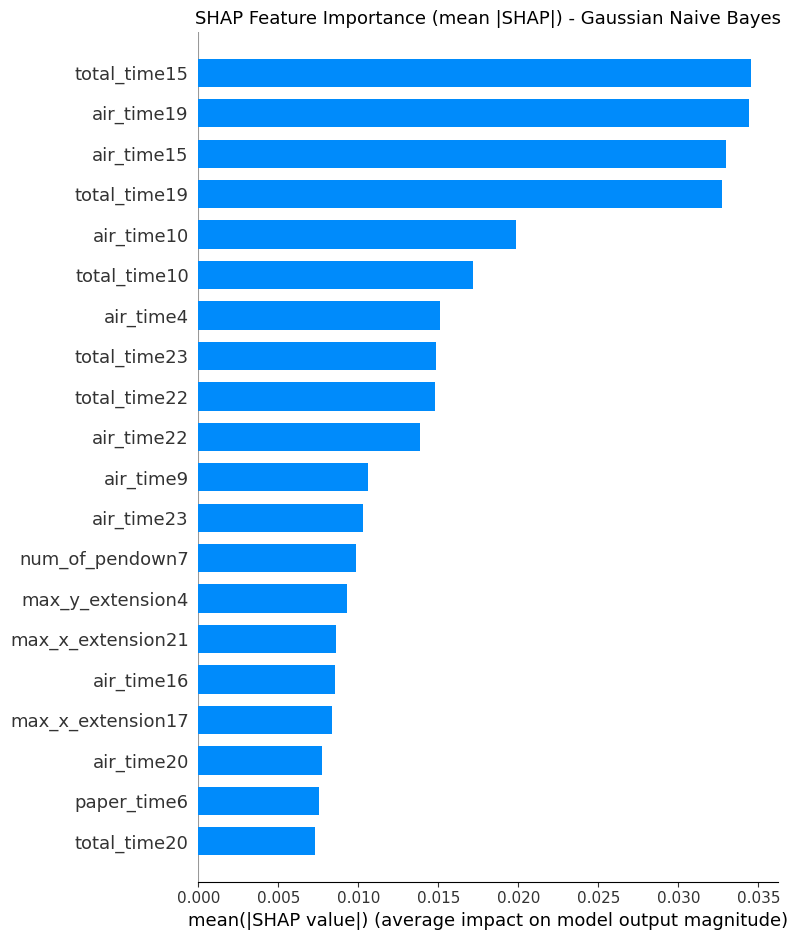

✔ Bar plot guardado.


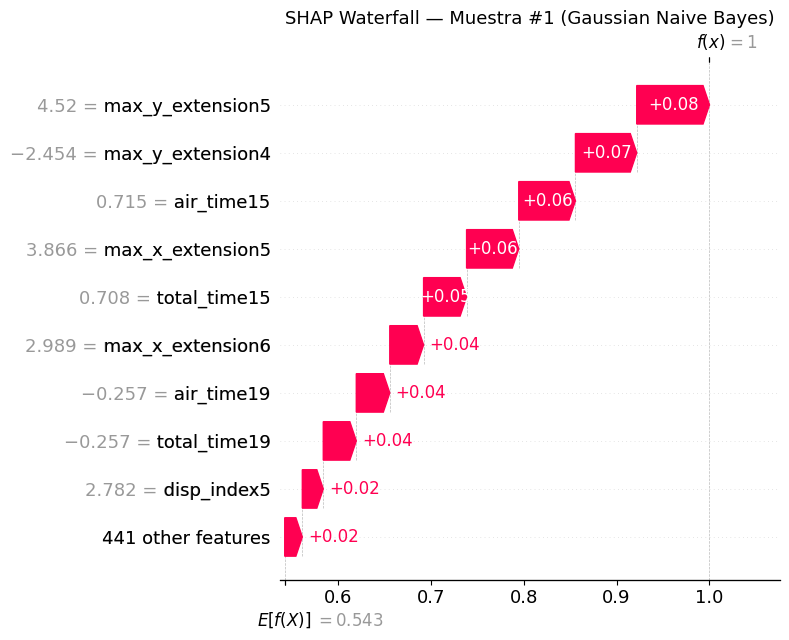

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

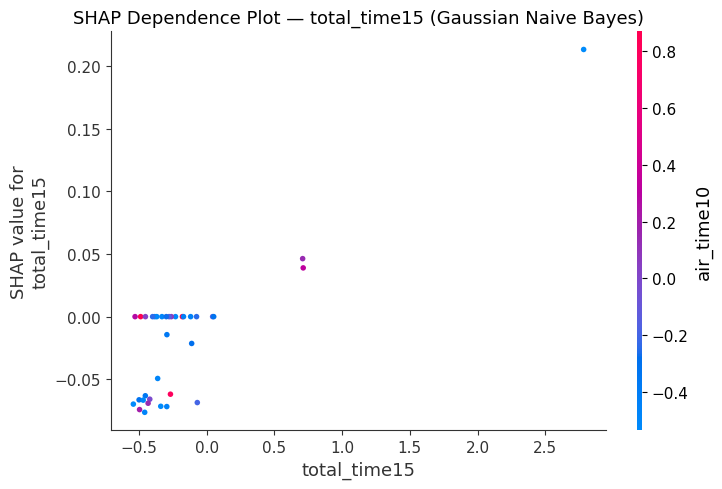

✔ Dependence plot guardado para: total_time15

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===
     Feature  Mean |SHAP|
total_time15     0.034519
  air_time19     0.034432
  air_time15     0.032986
total_time19     0.032714
  air_time10     0.019856
total_time10     0.017147
   air_time4     0.015069
total_time23     0.014857
total_time22     0.014801
  air_time22     0.013830


In [15]:
# ============================================================
# ANÁLISIS SHAP PARA GAUSSIAN NAIVE BAYES
# ============================================================

background = shap.sample(X_train_scaled, 100)  # 100 muestras como background

# Explainer 
explainer_gnb = shap.KernelExplainer(gnb.predict_proba, background)

# SHAP values
shap_values_gnb = explainer_gnb.shap_values(X_test_scaled, nsamples="auto")

# Se verifica la estructura
print("Shape shap_values_gnb:", np.array(shap_values_gnb).shape)


# Se extrae la clase positiva (P = 1)
sv_gnb = shap_values_gnb[:, :, 1]  # shape (35, 450)
print("Shape sv_gnb:", sv_gnb.shape)

# Se convierte X_test_scaled a DataFrame para que los plots usen nombres de features
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns.tolist())

# expected_value para clase positiva
ev = np.array(explainer_gnb.expected_value)
print("expected_value shape:", ev.shape)
print("expected_value:", ev)

# Si ev tiene shape (n_muestras, 2) se usa la media; si es (2,) usamos índice 1
if ev.ndim == 2:
    base_val = ev[:, 1].mean()
elif ev.ndim == 1:
    base_val = ev[1]
else:
    base_val = float(ev)

print("base_val usado:", base_val)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_gnb,
    X_test_df,
    show=False
)
plt.title("SHAP Summary Plot - Gaussian Naive Bayes (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv_gnb,
    X_test_df,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Gaussian Naive Bayes", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 1

explanation_gnb = shap.Explanation(
    values=sv_gnb[sample_idx],
    base_values=base_val,
    data=X_test_df.iloc[sample_idx],
    feature_names=X.columns.tolist()
)
plt.figure()
shap.plots.waterfall(explanation_gnb, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Gaussian Naive Bayes)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_gnb = np.abs(sv_gnb).mean(axis=0)
top_feature_idx_gnb = np.argmax(mean_abs_shap_gnb)
top_feature_name_gnb = X.columns[top_feature_idx_gnb]

plt.figure()
shap.dependence_plot(
    top_feature_idx_gnb,
    sv_gnb,
    X_test_df,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_gnb} (Gaussian Naive Bayes)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_gnb_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_gnb}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_gnb_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_gnb
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===")
print(feature_importance_gnb_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 1 (Gaussian Naive Bayes) ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000

Top features (peso LIME):
  -0.26 < total_time19 <= -0.25                  +0.1297
  -0.26 < air_time19 <= -0.25                    +0.1258
  -0.11 < air_time22 <= -0.08                    -0.0760
  -0.12 < total_time22 <= -0.07                  -0.0623
  air_time15 > -0.10                             +0.0563
  -0.56 < mean_speed_in_air21 <= -0.28           -0.0423
  gmrt_on_paper5 > 0.25                          -0.0415
  -0.41 < mean_jerk_in_air14 <= 0.39             +0.0385
  total_time15 > -0.05                           +0.0379
  mean_jerk_on_paper2 <= -0.52                   +0.0359
  -0.26 < air_time20 <= -0.22                    -0.0338
  gmrt_on_paper25 <= -0.61                       -0.0318
  -0.23 < mean_gmrt10 <= 0.55                    -0.0297
  0.29 < max_y_extension19 <= 0.41               -0.0295
  disp_index6 > 0.39                             +0.

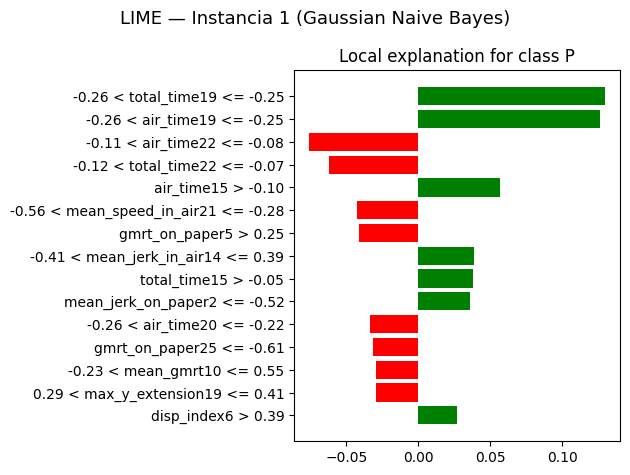


Calculando importancia global LIME (GNB)...

Top-20 features por importancia global LIME (Gaussian Naive Bayes):
   1. total_time1                               0.17522
   2. air_time1                                 0.16597
   3. air_time2                                 0.12183
   4. max_x_extension7                          0.10312
   5. total_time7                               0.10191
   6. mean_acc_in_air6                          0.09883
   7. disp_index9                               0.09130
   8. max_y_extension9                          0.09025
   9. total_time2                               0.08996
  10. max_x_extension3                          0.08766
  11. mean_acc_on_paper9                        0.08517
  12. mean_jerk_in_air9                         0.08514
  13. pressure_var8                             0.08348
  14. num_of_pendown9                           0.08227
  15. mean_acc_on_paper2                        0.07678
  16. mean_acc_on_paper7                      

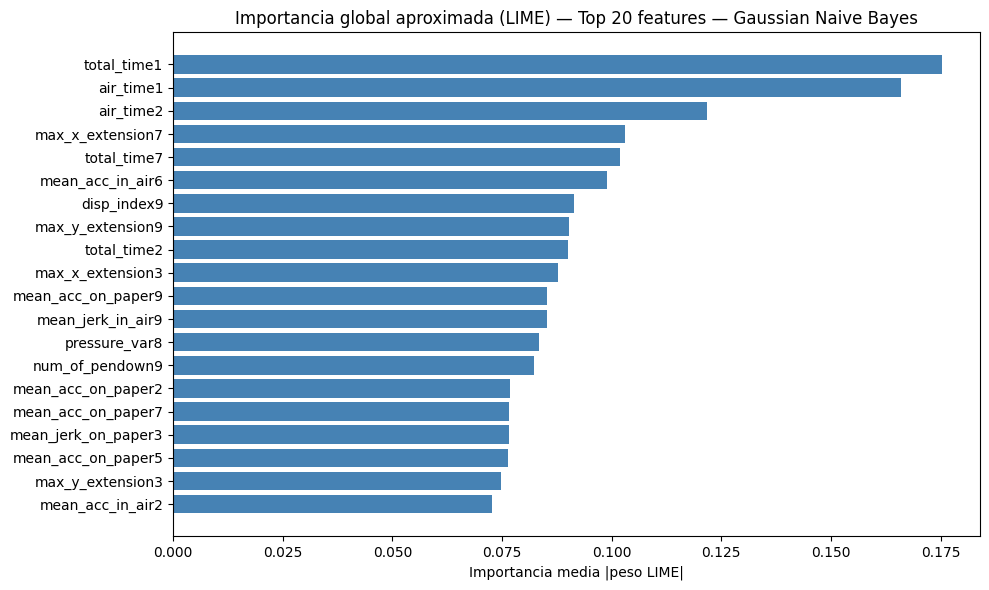

In [16]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO GNB
# ─────────────────────────────────────────

# Explainer
explainer_lime_gnb = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 1) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp_gnb = explainer_lime_gnb.explain_instance(
    data_row     = instance,
    predict_fn   = gnb.predict_proba,
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} (Gaussian Naive Bayes) ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {gnb.predict([instance])[0]}")
print(f"Probabilidades : H={gnb.predict_proba([instance])[0][0]:.3f} | "
      f"P={gnb.predict_proba([instance])[0][1]:.3f}")

print("\nTop features (peso LIME):")
for feat, weight in exp_gnb.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp_gnb.as_pyplot_figure()
fig.suptitle(f"LIME — Instancia {INSTANCE_IDX} (Gaussian Naive Bayes)", fontsize=13)
fig.tight_layout()
plt.savefig("lime_gnb_instance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (GNB)...")

all_weights_gnb = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer_lime_gnb.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = gnb.predict_proba,
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights_gnb[col].append(abs(weight))
                break

global_importance_gnb = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights_gnb.items()
}

top_global_gnb = sorted(global_importance_gnb.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (Gaussian Naive Bayes):")
for rank, (feat, score) in enumerate(top_global_gnb, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats_gnb, scores_gnb = zip(*top_global_gnb)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats_gnb[::-1], scores_gnb[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features — Gaussian Naive Bayes")
plt.tight_layout()
plt.savefig("lime_gnb_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()